# IPL Win Predictor Analysis

### 📌 Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore") 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 

import pickle 

plt.style.use("dark_background")

## DATA LOADING

### 📌 Load Dataset

In [3]:
matches = pd.read_csv("../data/matches.csv") 
deliveries = pd.read_csv("../data/deliveries.csv") 

print("Matches Shape:", matches.shape) 
print("Deliveries Shape:", deliveries.shape)

Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)


### 📌 Preview Data

In [4]:
matches.head()
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## DATA CLEANING

### 📌 Check Missing Values

In [5]:
print(matches.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


### 📌 Remove Unnecessary Columns

In [6]:
matches = matches[['id', 'city', 'winner']] 
matches.head()

,id,city,winner
0,335982,Bangalore,Kolkata Knight Riders
1,335983,Chandigarh,Chennai Super Kings
2,335984,Delhi,Delhi Daredevils
3,335985,Mumbai,Royal Challengers Bangalore
4,335986,Kolkata,Kolkata Knight Riders


### 📌 Merge Datasets

In [7]:
df = deliveries.merge(matches, left_on='match_id', right_on='id') 

df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,city,winner
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders


### 📌 Total Score Per Innings

In [8]:
total_score_df = df.groupby(['match_id', 'inning']).sum()['total_runs'].reset_index() 

total_score_df.head()

,match_id,inning,total_runs
0,335982,1,222
1,335982,2,82
2,335983,1,240
3,335983,2,207
4,335984,1,129


### 📌 First Innings Score

In [9]:
first_innings = total_score_df[total_score_df['inning'] == 1] 

first_innings.head()

,match_id,inning,total_runs
0,335982,1,222
2,335983,1,240
4,335984,1,129
6,335985,1,165
8,335986,1,110


### 📌 Add Target

In [10]:
match_df = df.merge(first_innings[['match_id', 'total_runs']], on='match_id') 

match_df.rename(columns={'total_runs_y': 'target'}, inplace=True) 

match_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,total_runs_x,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,city,winner,target
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,1,legbyes,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders,222
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,0,NaN,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders,222
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,1,wides,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders,222
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,0,NaN,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders,222
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,0,NaN,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders,222


## FILTER SECOND INNINGS

In [11]:
match_df = match_df[match_df['inning'] == 2] 

match_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,total_runs_x,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,city,winner,target
124,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,R Dravid,AB Dinda,W Jaffer,1,...,1,NaN,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders,222
125,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,2,W Jaffer,AB Dinda,R Dravid,0,...,1,wides,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders,222
126,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,3,W Jaffer,AB Dinda,R Dravid,0,...,0,NaN,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders,222
127,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,4,W Jaffer,AB Dinda,R Dravid,1,...,1,NaN,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders,222
128,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,5,R Dravid,AB Dinda,W Jaffer,1,...,1,NaN,0,NaN,NaN,NaN,335982,Bangalore,Kolkata Knight Riders,222


## FEATURE ENGINEERING

### 📌 Current Score

In [12]:
match_df['current_score'] = match_df.groupby('match_id')['total_runs_x'].cumsum()

### 📌 Runs Left

In [13]:
match_df['runs_left'] = match_df['target'] - match_df['current_score']

### 📌 Balls Left

In [14]:
match_df['balls_left'] = 120 - ( (match_df['over'] - 1) * 6 + match_df['ball'] )

### 📌 Wickets Left

In [15]:
match_df['player_dismissed'] = match_df['player_dismissed'].fillna("0") 

match_df['wickets'] = match_df['player_dismissed'].apply( lambda x: 0 if x == "0" else 1 ) 

match_df['wickets_fallen'] = match_df.groupby('match_id')['wickets'].cumsum() 

match_df['wickets_left'] = 10 - match_df['wickets_fallen']

### 📌 Current Run Rate

In [16]:
match_df['crr'] = ( match_df['current_score'] * 6 ) / ( 120 - match_df['balls_left'] )

### 📌 Required Run Rate

In [17]:
match_df['rrr'] = ( match_df['runs_left'] * 6 ) / match_df['balls_left']

### 📌 Result Column

In [18]:
match_df['batting_team_win'] = np.where( match_df['batting_team'] == match_df['winner'], 1, 0 )

## FINAL DATASET

In [19]:
final_df = match_df[[ 
    'batting_team', 
    'bowling_team', 
    'city', 
    'runs_left', 
    'balls_left', 
    'wickets_left', 
    'target', 
    'crr', 
    'rrr', 
    'batting_team_win' 
]] 

final_df = final_df.dropna() 

final_df.head()

,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,target,crr,rrr,batting_team_win
124,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,221,125,10,222,-1.2,10.608000,0
125,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,220,124,10,222,-3.0,10.645161,0
126,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,220,123,10,222,-4.0,10.731707,0
127,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,219,122,10,222,-9.0,10.770492,0
128,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,218,121,10,222,-24.0,10.809917,0


## EDA

### 📌 Winning Teams

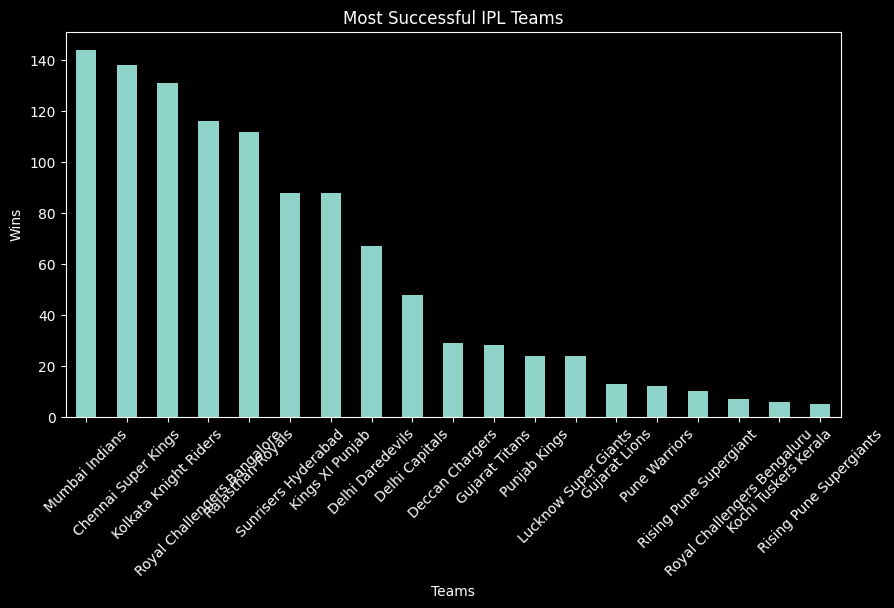

In [20]:
plt.figure(figsize=(10,5)) 

matches['winner'].value_counts().plot(kind='bar') 

plt.title("Most Successful IPL Teams") 
plt.xlabel("Teams") 
plt.ylabel("Wins") 

plt.xticks(rotation=45) 

plt.show()

### 📌 Toss Impact

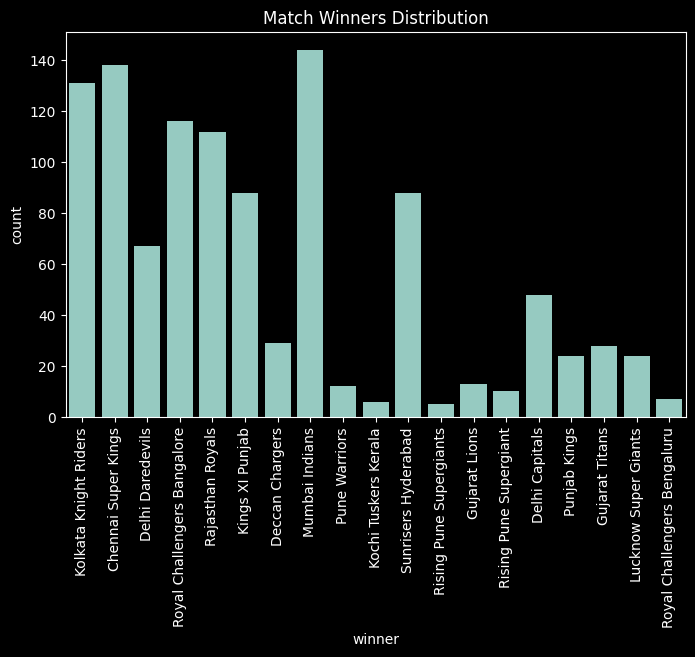

In [21]:
plt.figure(figsize=(8,5)) 

sns.countplot(x='winner', data=matches) 

plt.xticks(rotation=90) 
plt.title("Match Winners Distribution") 

plt.show()

### 📌 Target Distribution

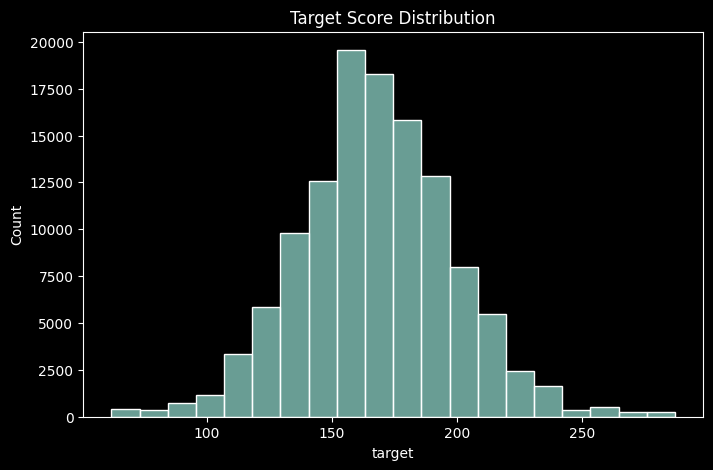

In [22]:
plt.figure(figsize=(8,5)) 

sns.histplot(final_df['target'], bins=20) 

plt.title("Target Score Distribution") 

plt.show()

### 📌 Correlation Heatmap

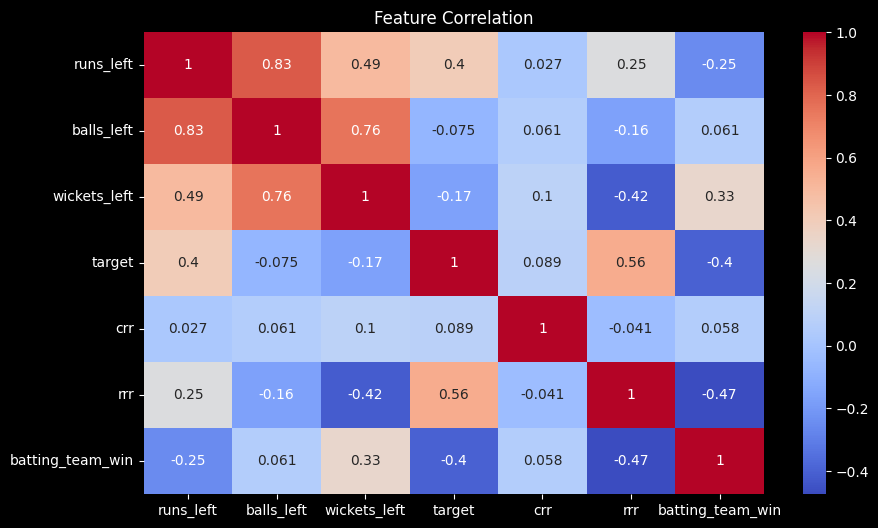

In [23]:
numeric_df = final_df.select_dtypes(include=np.number) 

plt.figure(figsize=(10,6)) 
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm') 
plt.title("Feature Correlation") 

plt.show()

## ENCODING

In [24]:
team_encoder = LabelEncoder() 
venue_encoder = LabelEncoder() 

final_df['batting_team'] = team_encoder.fit_transform(final_df['batting_team']) 
final_df['bowling_team'] = team_encoder.transform(final_df['bowling_team']) 
final_df['city'] = venue_encoder.fit_transform(final_df['city'])

### Replace Infinite Values

In [25]:
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

final_df.dropna(inplace=True)

print(final_df.isnull().sum())

batting_team        0
bowling_team        0
city                0
runs_left           0
balls_left          0
wickets_left        0
target              0
crr                 0
rrr                 0
batting_team_win    0
dtype: int64


## TRAIN TEST SPLIT

In [26]:
X = final_df.drop('batting_team_win', axis=1) 
y = final_df['batting_team_win'] 

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 ) 

print("Training Shape:", X_train.shape) 
print("Testing Shape:", X_test.shape)

Training Shape: (94950, 9)
Testing Shape: (23738, 9)


## MODEL TRAINING

### 📌 Logistic Regression

In [27]:
lr_model = LogisticRegression(max_iter=1000) 

lr_model.fit(X_train, y_train) 
lr_pred = lr_model.predict(X_test) 
lr_acc = accuracy_score(y_test, lr_pred) 

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7811947089055523


### 📌 Random Forest

In [28]:
rf_model = RandomForestClassifier( n_estimators=100, random_state=42 ) 

rf_model.fit(X_train, y_train) 
rf_pred = rf_model.predict(X_test) 
rf_acc = accuracy_score(y_test, rf_pred) 

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9973460274665094


## MODEL COMPARISON

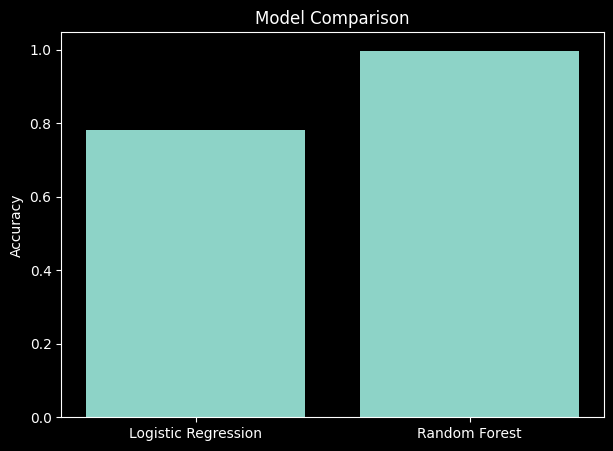

In [30]:
models = ['Logistic Regression', 'Random Forest'] 
scores = [lr_acc, rf_acc] 

plt.figure(figsize=(7,5)) 
plt.bar(models, scores) 
plt.ylabel("Accuracy") 
plt.title("Model Comparison") 

plt.show()

### 📌 Best Model

In [31]:
best_model = rf_model if rf_acc > lr_acc else lr_model 

print("Best Model Selected:") 
print(type(best_model).__name__)

Best Model Selected:
RandomForestClassifier


## CONFUSION MATRIX

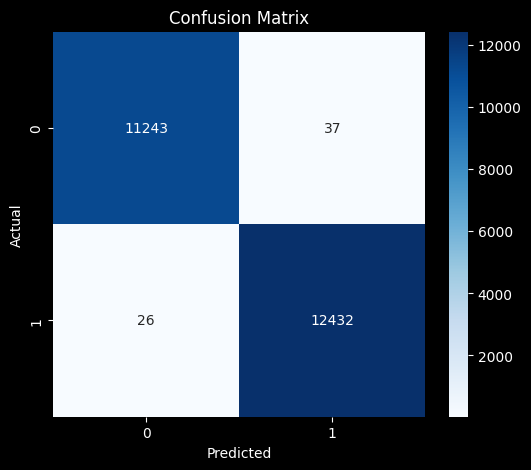

In [32]:
cm = confusion_matrix(y_test, rf_pred) 

plt.figure(figsize=(6,5)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.title("Confusion Matrix") 

plt.show()

### 📌 Classification Report

In [33]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11280
           1       1.00      1.00      1.00     12458

    accuracy                           1.00     23738
   macro avg       1.00      1.00      1.00     23738
weighted avg       1.00      1.00      1.00     23738



## SAVE MODEL

In [34]:
with open("../model/ipl_model.pkl", "wb") as f: pickle.dump(best_model, f) 

encoders = { "team": team_encoder, "venue": venue_encoder } 

with open("../model/encoders.pkl", "wb") as f: pickle.dump(encoders, f) 

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


## PREDICTION TESTING

In [35]:
sample = pd.DataFrame({ 'batting_team': [team_encoder.transform(['Mumbai Indians'])[0]], 'bowling_team': [team_encoder.transform(['Chennai Super Kings'])[0]], 'city': [venue_encoder.transform(['Mumbai'])[0]], 'runs_left': [45], 'balls_left': [30], 'wickets_left': [6], 'target': [180], 'crr': [8.5], 'rrr': [9.0] }) 

sample

,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,target,crr,rrr
0,10,0,26,45,30,6,180,8.5,9.0


### 📌 Predict Probability

In [36]:
prob = best_model.predict_proba(sample) 

print("Batting Team Win Probability:", round(prob[0][1] * 100, 2), "%") 
print("Bowling Team Win Probability:", round(prob[0][0] * 100, 2), "%")

Batting Team Win Probability: 84.0 %
Bowling Team Win Probability: 16.0 %


## FEATURE IMPORTANCE

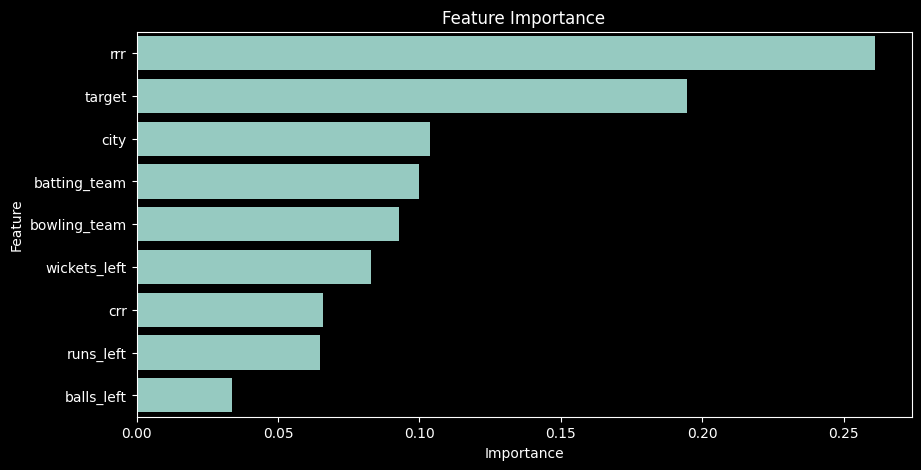

In [37]:
if hasattr(best_model, "feature_importances_"): importance = pd.DataFrame({ 'Feature': X.columns, 'Importance': best_model.feature_importances_ }) 

importance = importance.sort_values( by='Importance', ascending=False ) 
plt.figure(figsize=(10,5)) 
sns.barplot( x='Importance', y='Feature', data=importance ) 
plt.title("Feature Importance") 

plt.show()

## FINAL MESSAGE

In [38]:
print("🏏 IPL Win Predictor Analysis Completed Successfully")

🏏 IPL Win Predictor Analysis Completed Successfully
